# Sentimentální analýza nad data scrape nad Alzou
zdroj dat: viz adresář ke scrape z Alza

In [2]:
import pandas as pd
!pip install deep-translator

In [3]:
data = pd.read_csv("/content/drive/MyDrive/00a AKTUALNI/KURZY - OSVC vzdelavani/2025-05 - Data analyst (CodersLab)/4 - Data vizualization/den 2/analyza - sentimentalni/data.csv")

In [4]:
data

,Unnamed: 0,review,rating
0,0,Nejlepší hodinky pro běžné užívání,100
1,1,Vetsi display nez predchozi model,100
2,2,Pěkné hodinky\r\n,100
3,3,"nemajú chybu, spĺňajú všetko čo som od nich oč...",100
4,4,hodinky splnili očekávání.,100
...,...,...,...
853,853,Snadnější přístup k základním informacím - kom...,100
854,854,Manželka spokojená po přechodu z modelu SE,100
855,855,Prostě Apple Watch. Kdo to jednou zkusí už nec...,100
856,856,"Hezčí, větší, rychlejší",100


In [5]:
data.rating.unique()

array([100,  80,  40,  60,  20])

In [6]:
data[data.rating == 60]

,Unnamed: 0,review,rating
47,47,Kompatibilne Esim pre tieto hodinky na Slovens...,60
50,50,Dodanie bolo predlzene o mesiac neskor aj ste ...,60
73,73,Hodiny fungují bez problemů,60
96,96,Hodiny fungují bez problemů,60
132,132,"je to fajn, prešiel som z watch 5, je to urcit...",60
135,135,Hodiny fungují bez problemů,60
179,179,Hodiny fungují bez problemů,60
213,213,Hodiny fungují bez problemů,60
264,264,Hodiny fungují bez problemů,60
303,303,Hodiny fungují bez problemů,60


# PŘEKLAD Z CZ NA ANJ

budeme pracovat s API: https://pypi.org/project/deep-translator/

In [7]:
# 1️⃣ Instalace knihovny
!pip install deep-translator

# 2️⃣ Překlad po dávkách s ukládáním průběhu
import pandas as pd
from deep_translator import GoogleTranslator
import time
import os

# Cesty k souborům
INPUT_PATH = "/content/drive/MyDrive/00a AKTUALNI/KURZY - OSVC vzdelavani/2025-05 - Data analyst (CodersLab)/4 - Data vizualization/den 2/analyza - sentimentalni/data.csv"
OUTPUT_PATH = "/content/drive/MyDrive/00a AKTUALNI/KURZY - OSVC vzdelavani/2025-05 - Data analyst (CodersLab)/4 - Data vizualization/den 2/analyza - sentimentalni/data_en.csv"

# Načtení dat
df = pd.read_csv(INPUT_PATH)

# Pokud už existuje částečný výstup, načti ho a navážeme
if os.path.exists(OUTPUT_PATH):
    df_translated = pd.read_csv(OUTPUT_PATH)
    if "review_en" in df_translated.columns:
        df["review_en"] = df_translated["review_en"]
    else:
        df["review_en"] = None
    print("🔄 Pokračuji v překladu z uloženého souboru.")
else:
    df["review_en"] = None
    print("▶️ Začínám nový překlad.")

translator = GoogleTranslator(source="cs", target="en")

batch_size = 50

for start in range(0, len(df), batch_size):
    end = min(start + batch_size, len(df))
    batch = df.iloc[start:end]

    # kontrola, zda už tato dávka byla přeložená
    if batch["review_en"].notna().all():
        continue

    print(f"Překládám řádky {start}–{end-1}...")

    for idx, row in batch.iterrows():
        if pd.isna(row["review_en"]):
            try:
                translated = translator.translate(str(row["review"]))
            except Exception as e:
                print(f"⚠️ Chyba na řádku {idx}: {e}")
                translated = ""
            df.at[idx, "review_en"] = translated
            time.sleep(0.2)  # pauza proti blokaci

    # průběžné ukládání
    df.to_csv(OUTPUT_PATH, index=False)
    print(f"💾 Uloženo {end} řádků do {OUTPUT_PATH}")

print("✅ Překlad dokončen a uložen.")


🔄 Pokračuji v překladu z uloženého souboru.
✅ Překlad dokončen a uložen.


In [8]:
data_en = pd.read_csv("/content/drive/MyDrive/00a AKTUALNI/KURZY - OSVC vzdelavani/2025-05 - Data analyst (CodersLab)/4 - Data vizualization/den 2/analyza - sentimentalni/data_en.csv")

In [9]:
data_en

,Unnamed: 0,review,rating,review_en
0,0,Nejlepší hodinky pro běžné užívání,100,The best watch for normal use
1,1,Vetsi display nez predchozi model,100,A larger display than the previous model
2,2,Pěkné hodinky\r\n,100,Nice watch
3,3,"nemajú chybu, spĺňajú všetko čo som od nich oč...",100,"no mistake, a lot of all"
4,4,hodinky splnili očekávání.,100,The watch met expectations.
...,...,...,...,...
853,853,Snadnější přístup k základním informacím - kom...,100,Easier access to basic information - communica...
854,854,Manželka spokojená po přechodu z modelu SE,100,Wife satisfied after switching from the model ...
855,855,Prostě Apple Watch. Kdo to jednou zkusí už nec...,100,Just Apple Watch. Whoever wants to try it anym...
856,856,"Hezčí, větší, rychlejší",100,"Nicer, larger, faster"


In [10]:
data_en.rating.unique()

array([100,  80,  40,  60,  20])

DALŠÍ KROKY

Nahradit hodnocení 3 kategoriemi:
- negativní 20
- neutrální 40, 60
- positivní 80, 100

Kolik je v každé katorii záznamů

Odstranit duplicity

# PŘEVOD ČÍSELNÉHO RATINGU NA SLOVNÍ

In [11]:
# Funkce pro převod rating -> sentiment
def map_rating_to_sentiment(rating: int) -> str:
    if rating == 20:
        return "negative"
    elif rating in [40, 60]:
        return "neutral"
    elif rating in [80, 100]:
        return "positive"
    else:
        return "unknown"  # pro případ jiných hodnot

# Přidání nového sloupce
data_en["sentiment"] = data_en["rating"].apply(map_rating_to_sentiment)

# Kontrola výsledku
print(data_en["sentiment"].value_counts())


sentiment
positive    806
neutral      33
negative     19
Name: count, dtype: int64


In [12]:
data_en

,Unnamed: 0,review,rating,review_en,sentiment
0,0,Nejlepší hodinky pro běžné užívání,100,The best watch for normal use,positive
1,1,Vetsi display nez predchozi model,100,A larger display than the previous model,positive
2,2,Pěkné hodinky\r\n,100,Nice watch,positive
3,3,"nemajú chybu, spĺňajú všetko čo som od nich oč...",100,"no mistake, a lot of all",positive
4,4,hodinky splnili očekávání.,100,The watch met expectations.,positive
...,...,...,...,...,...
853,853,Snadnější přístup k základním informacím - kom...,100,Easier access to basic information - communica...,positive
854,854,Manželka spokojená po přechodu z modelu SE,100,Wife satisfied after switching from the model ...,positive
855,855,Prostě Apple Watch. Kdo to jednou zkusí už nec...,100,Just Apple Watch. Whoever wants to try it anym...,positive
856,856,"Hezčí, větší, rychlejší",100,"Nicer, larger, faster",positive


# PRÁCE S DUPLICITAMI - IDENTIFIKACE

In [13]:
n_total = data_en.shape[0]
print("Celkový počet recenzí:", n_total)

n_unique = data_en["review"].nunique()
print("Počet unikátních recenzí:", n_unique)

print("Počet duplicitních řádků:", n_total - n_unique)


Celkový počet recenzí: 858
Počet unikátních recenzí: 149
Počet duplicitních řádků: 709


In [14]:
dup_texts = data_en["review"].value_counts()
dup_texts = dup_texts[dup_texts > 1]

print(f"Počet unikátních duplicitních textů: {dup_texts.shape[0]}")
display(dup_texts.head(20))

Počet unikátních duplicitních textů: 81


,count
review,
Super,33
Na baterce vydrží jeden den.,19
Apple,19
super kvalita od ,19
Hodinky super,19
Povedený kousek elektroniky..nezbytná součást k produktům od Applu.. maximální spokojenost.. určitě doporučuji..,19
Hodiny fungují bez problemů,19
funguje dle očekávání,19
Kvalita,19


# ODSTRANĚNÍ DUPLICIT

(mělo být na začátku, abych neposílal na překlad 800 řádků, ale pouze 150 unikátních)

In [15]:
import pandas as pd

# načtení původního datasetu
data_en = pd.read_csv("/content/drive/MyDrive/00a AKTUALNI/KURZY - OSVC vzdelavani/2025-05 - Data analyst (CodersLab)/4 - Data vizualization/den 2/analyza - sentimentalni/data_en.csv")

# odstranění duplicit podle 'review'
data_en_unique = data_en.drop_duplicates(subset=["review"], keep="first").reset_index(drop=True)

# uložení nového datasetu
output_path = "/content/drive/MyDrive/00a AKTUALNI/KURZY - OSVC vzdelavani/2025-05 - Data analyst (CodersLab)/4 - Data vizualization/den 2/analyza - sentimentalni/data_en_unique.csv"
data_en_unique.to_csv(output_path, index=False)

# statistiky
n_total = data_en.shape[0]
n_unique = data_en_unique.shape[0]
n_removed = n_total - n_unique
percent_removed = (n_removed / n_total) * 100

print(f"✅ Nový dataset uložen: {output_path}")
print(f"Celkem řádků původně: {n_total}")
print(f"Počet unikátních recenzí: {n_unique}")
print(f"Odstraněno duplicit: {n_removed} ({percent_removed:.2f} %)")


✅ Nový dataset uložen: /content/drive/MyDrive/00a AKTUALNI/KURZY - OSVC vzdelavani/2025-05 - Data analyst (CodersLab)/4 - Data vizualization/den 2/analyza - sentimentalni/data_en_unique.csv
Celkem řádků původně: 858
Počet unikátních recenzí: 149
Odstraněno duplicit: 709 (82.63 %)


# PRÁCE POUZE S UNIKÁTNÍM VÝSKYTEM

In [16]:
data_en_unique = pd.read_csv("/content/drive/MyDrive/00a AKTUALNI/KURZY - OSVC vzdelavani/2025-05 - Data analyst (CodersLab)/4 - Data vizualization/den 2/analyza - sentimentalni/data_en_unique.csv")

In [18]:
data_en_unique

,Unnamed: 0,review,rating,review_en
0,0,Nejlepší hodinky pro běžné užívání,100,The best watch for normal use
1,1,Vetsi display nez predchozi model,100,A larger display than the previous model
2,2,Pěkné hodinky\r\n,100,Nice watch
3,3,"nemajú chybu, spĺňajú všetko čo som od nich oč...",100,"no mistake, a lot of all"
4,4,hodinky splnili očekávání.,100,The watch met expectations.
...,...,...,...,...
144,595,Vysoká odolnosť oproti hliníkovým modelom,100,High resistance compared to aluminum modelom
145,669,Povedený kousek,80,Hilarious
146,672,splnilo očekávání,100,has met expectations
147,676,"Lehke, praktictejsi pro bezne noseni nez ultra...",100,"Light, practical for us to be worn than ultra ..."


# PŘEVOD RATING NA SLOVNÍ HODNOCENÍ
(znovu; neb v novém souboru kde jsou pouze unikátní hodnoty. Mělo být v půdovním, kdy bych vytovřil a uložil tento nový sloupec, abych nevytvářel znovu)

In [20]:
# Funkce pro převod rating -> sentiment
def map_rating_to_sentiment(rating: int) -> str:
    if rating == 20:
        return "negative"
    elif rating in [40, 60]:
        return "neutral"
    elif rating in [80, 100]:
        return "positive"
    else:
        return "unknown"  # pro případ jiných hodnot

# Přidání nového sloupce
data_en_unique["sentiment"] = data_en_unique["rating"].apply(map_rating_to_sentiment)

In [21]:
# Kontrola výsledku
print(data_en_unique["sentiment"].value_counts())

sentiment
positive    134
neutral      13
negative      2
Name: count, dtype: int64


In [24]:
# Vypsání všech řádků se sentimentem "neutral"
neutral_rows = data_en_unique[data_en_unique["sentiment"] == "neutral"]

print(f"Počet neutrálních recenzí: {neutral_rows.shape[0]}")
display(neutral_rows.head(20))  # ukázka prvních 20


Počet neutrálních recenzí: 13


,Unnamed: 0,review,rating,review_en,sentiment
18,18,Koupeno rozbalené..,40,Bought unpacked ..,neutral
35,35,Funkčně pecka odolnostně tragédie.... Nerozumí...,40,Functionally stroke resistance tragedy .... I ...,neutral
47,47,Kompatibilne Esim pre tieto hodinky na Slovens...,60,Compatible essays over TiTo watches in Slovaki...,neutral
49,49,Hodinky sa poskriabali hned v prvy den a to be...,40,The watch was scratched in the first day of th...,neutral
50,50,Dodanie bolo predlzene o mesiac neskor aj ste ...,60,Dodanie was presented about the Mesiac Neskor ...,neutral
51,51,to ze maju hodinky slabu vydrz na bateriu som ...,40,The watches of the weak can hold on the batter...,neutral
68,69,watchOS,40,watchos,neutral
72,73,Hodiny fungují bez problemů,60,The clock works without problems,neutral
97,106,Zatím čekám až se předchozí majitel uráčí smaz...,40,So far I wait for the previous owner to delete...,neutral
103,112,"Naprosto neodolné, sklíčko je totální šrot.......",40,"Absolutely impatible, the slide is total scrap...",neutral


# ROZDĚLENÍ PRO TRÉNING A TEST

rozdeleny dataset na testovaci a trenovaci cast na texty a labels pomoci funkce z scikit learn a prevedene texty z trenovaciho a testovaciho datasetu do ciselne formy pomoci TF-IDF

In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1) Načtení datasetu z CSV souboru
PATH = "/content/drive/MyDrive/00a AKTUALNI/KURZY - OSVC vzdelavani/2025-05 - Data analyst (CodersLab)/4 - Data vizualization/den 2/analyza - sentimentalni/data_en_unique.csv"
data = pd.read_csv(PATH)  # načte data do Pandas DataFrame

# 2) Funkce pro převod ratingu (20/40/60/80/100) na kategorii sentimentu
def map_rating_to_sentiment(r):
    if r == 20:
        return "negative"   # hodnocení 20 = negativní recenze
    elif r in (40, 60):
        return "neutral"    # hodnocení 40 nebo 60 = neutrální recenze
    elif r in (80, 100):
        return "positive"   # hodnocení 80 nebo 100 = pozitivní recenze
    return None             # cokoliv jiného (kdyby se objevilo) = ignorujeme

# vytvoří nový sloupec 'sentiment' na základě sloupce 'rating'
data["sentiment"] = data["rating"].apply(map_rating_to_sentiment)

# 3) Odstraníme řádky, kde není definovaný sentiment (např. rating nebyl 20/40/60/80/100)
data = data.dropna(subset=["sentiment"]).reset_index(drop=True)

# odstraníme technický indexový sloupec (pokud existuje)
if "Unnamed: 0" in data.columns:
    data = data.drop(columns=["Unnamed: 0"])

# 4) Definujeme vstupy (X) a cíle (y)
X = data["review_en"].astype(str)    # vstupem je text recenze v angličtině
y = data["sentiment"].astype(str)    # cílem je náš cílový label sentiment (negative/neutral/positive)

# Zjistíme, kolik má nejméně zastoupená třída vzorků
min_count = y.value_counts().min()

# Nastavíme velikost testovací sady na 20 % (standardní volba)
test_size = 0.2
stratify_arg = y  # výchozí volba = stratifikace podle y, aby se zachovaly proporce tříd

# Pokud má některá třída méně než 2 vzorky → stratifikace není možná
if min_count < 2:
    stratify_arg = None  # vypneme stratifikaci

# Pokud by při test_size=0.2 měla nejmenší třída <1 vzorek v testu → zvětšíme test_size
elif int(min_count * test_size) < 1:
    test_size = min(0.5, max(0.2, 1 / min_count + 0.05))

# Rozdělíme dataset na trénovací a testovací část
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,   # velikost testovací sady
    random_state=42,       # seed pro opakovatelnost výsledků
    stratify=stratify_arg  # zajistí zachování poměru tříd (pokud to bylo možné)
)

# 5) Výpis výsledků
print(f"Train: {len(X_train)}, Test: {len(X_test)}, test_size={test_size:.2f}")
print("\nRozložení tříd (train):")
print(y_train.value_counts())  # ukáže, kolik je tříd v trénovací sadě
print("\nRozložení tříd (test):")
print(y_test.value_counts())   # ukáže, kolik je tříd v testovací sadě






Train: 74, Test: 75, test_size=0.50

Rozložení tříd (train):
sentiment
positive    67
neutral      6
negative     1
Name: count, dtype: int64

Rozložení tříd (test):
sentiment
positive    67
neutral      7
negative     1
Name: count, dtype: int64


## Dívám se na trénovací data

In [32]:
X_train

,review_en
53,A larger screen means better quick sight
74,Apple
75,"They look good, they work as they should."
12,As expected
30,"I have a watch briefly, compared to the Garmin..."
...,...
18,Bought unpacked ..
131,"Fulfilling Vsetko, what som from them ocakava,..."
15,"The watch is great, but if I knew they couldn'..."
0,The best watch for normal use


In [33]:
y_train

,sentiment
53,positive
74,positive
75,positive
12,positive
30,positive
...,...
18,neutral
131,positive
15,positive
0,positive


# feature engineering metodu TFIDF


když máme data rozdělená na trénovací a testovací sadu, další krok je vektorizace textů pomocí TF-IDF.

🔑 Co je TF-IDF

Term Frequency–Inverse Document Frequency

Převede text na číselný vektor → každé slovo dostane váhu podle toho, jak často se vyskytuje v dokumentu a jak moc je pro něj typické.

Výstupem je velká matice, kde každý řádek = recenze, každý sloupec = slovo (feature).

Výsledek

X_train_tfidf a X_test_tfidf jsou číselné matice, které už můžeš použít pro trénink klasifikačního modelu.

Například: X_train_tfidf.shape = (119, 5000) → 119 recenzí × 5000 slovních feature.

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1️⃣ Inicializace TF-IDF vektorizéru
vectorizer = TfidfVectorizer(
    max_features=5000,   # maximální počet slov (feature space)
    ngram_range=(1,2),   # unigrams a bigrams
    stop_words="english" # anglické stopwords
)

# 2️⃣ Fit na trénovací data a transformace
X_train_tfidf = vectorizer.fit_transform(X_train)

# 3️⃣ Transformace testovacích dat (už jen transform, ne fit!)
X_test_tfidf = vectorizer.transform(X_test)

print("Trénovací matice:", X_train_tfidf.shape)
print("Testovací matice:", X_test_tfidf.shape)


Trénovací matice: (74, 1091)
Testovací matice: (75, 1091)


# TF-IDF + Logistic Regression

Co uvidíš

Classification report: precision, recall, F1-score pro každou třídu (negative, neutral, positive).

Confusion matrix: graficky, kde model nejčastěji chybuje.

POUŽÍTÍ DVOU MODELŮ

Rozdíl:

1) LogisticRegression – rychlá, dobře funguje na textu, dává i pravděpodobnosti predikcí.

2) SVC (Support Vector Classifier) – často silný model pro text, ale:

- může být pomalejší na větších datech,

- standardně nedává pravděpodobnosti (jen labely),

- často funguje dobře s lineárním jádrem (kernel="linear").

AD 1) LogisticRegression – rychlá, dobře funguje na textu, dává i pravděpodobnosti predikcí.

📊 Classification report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         1
     neutral       0.00      0.00      0.00         7
    positive       0.89      0.99      0.94        67

    accuracy                           0.88        75
   macro avg       0.30      0.33      0.31        75
weighted avg       0.80      0.88      0.84        75



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


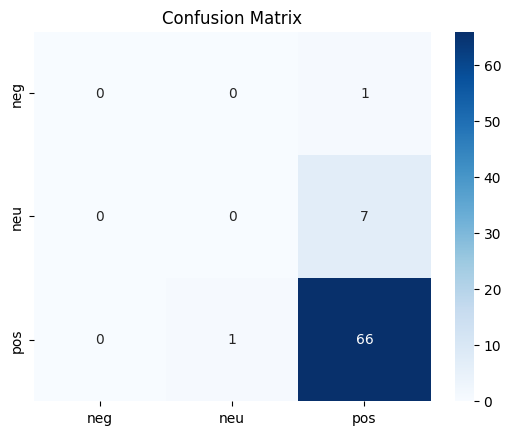

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ Inicializace modelu
clf = LogisticRegression(max_iter=1000, class_weight="balanced")

# 2️⃣ Trénink na TF-IDF vektorech
clf.fit(X_train_tfidf, y_train)

# 3️⃣ Predikce na testovacích datech
y_pred = clf.predict(X_test_tfidf)

# 4️⃣ Vyhodnocení
print("📊 Classification report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=["negative","neutral","positive"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["neg","neu","pos"],
            yticklabels=["neg","neu","pos"])
plt.title("Confusion Matrix")
plt.show()


# INTERPRETACE VÝSLEDKU

🔎 Confusion Matrix

Řádky = skutečný sentiment

Sloupce = predikovaný sentiment

Výsledky:

negative (1 vzorek) → model ho predikoval jako positive.

neutral (7 vzorků) → všech 7 model označil jako positive.

positive (67 vzorků) → 66 správně, 1 špatně (označen jako neutral).


📌 Model tedy všechny recenze označuje jako positive (kromě jedné chyby na neutral).


🔎 Classification report

negative

precision = 0.00 (nikdy neuhodl negativní)

recall = 0.00 (z 1 negativní recenze žádnou netrefil)

neutral

precision = 0.00 (každou neutral označil jako positive)

recall = 0.00 (žádnou netrefil správně)

positive

precision = 0.89 (z predikovaných "positive" bylo 89 % správně)

recall = 0.99 (skoro všechny skutečně positive zachytil)

accuracy = 0.88 (88 %) – vysoká, ale zavádějící, protože většina dat je positive.

macro avg (0.30–0.33) – průměr přes všechny třídy, ukazuje slabý výkon na minoritních třídách.

weighted avg (0.80–0.88) – vážený průměr podle počtu vzorků, „maskuje“ selhání u neutral/negative.


📌 Interpretace

Model se naučil dobře rozpoznávat pozitivní recenze, protože jich má drtivou většinu (67 z 75 v testu).

Ale úplně selhává u negativních a neutrálních recenzí – důvodem je nevyvážený dataset (v tréninku i testu bylo těchto tříd málo).


🔧 Co s tím?

Vyvážit dataset

Nasbírat víc negativních a neutrálních recenzí.

Nebo použít techniky jako oversampling (SMOTE) / undersampling majority class.

Použít vhodnější model

Např. LinearSVC nebo RandomForestClassifier, které někdy lépe zvládají nevyvážená data.

Použít jiné metriky než accuracy

Např. macro F1-score, protože accuracy je u nevyvážených dat zavádějící.

Experimentovat s TF-IDF parametry

ngram_range=(1,3), min_df=2, odstranění stopwords, lemmatizace.

AD 2) SVC (Support Vector Classifier)

📊 Classification report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         1
     neutral       0.00      0.00      0.00         7
    positive       0.89      0.99      0.94        67

    accuracy                           0.88        75
   macro avg       0.30      0.33      0.31        75
weighted avg       0.80      0.88      0.84        75



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


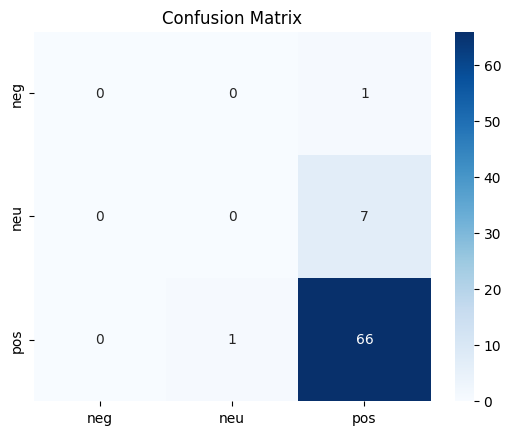

In [34]:
from sklearn.svm import SVC

# Inicializace modelu (lineární kernel, vyvážené váhy tříd)
clf = SVC(kernel="linear", class_weight="balanced")

# Trénink
clf.fit(X_train_tfidf, y_train)

# Predikce
y_pred = clf.predict(X_test_tfidf)

# Vyhodnocení (stejné jako předtím)
print("📊 Classification report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=["negative","neutral","positive"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["neg","neu","pos"],
            yticklabels=["neg","neu","pos"])
plt.title("Confusion Matrix")
plt.show()


# INTERPRETACE VÝSLEDKU

🔎 Confusion Matrix

Řádky = skutečné hodnoty, sloupce = predikce.

negative (1 vzorek) → predikován jako positive.

neutral (7 vzorků) → všechny predikovány jako positive.

positive (67 vzorků) → 66 správně, 1 špatně jako neutral.

📌 Model opět úplně ignoruje minority class (negative, neutral) a předpovídá skoro všechno jako positive.

🔎 Classification Report

negative (jen 1 vzorek v testu)

precision = 0.00 (nepředpověděl nikdy negative)

recall = 0.00 (z 1 vzorku netrefil žádný)

f1 = 0.00

neutral (7 vzorků v testu)

precision = 0.00 (všechny označeny jako positive)

recall = 0.00

f1 = 0.00

positive (67 vzorků v testu)

precision = 0.89 → z předpovězených "positive" bylo 89 % správně

recall = 0.99 → zachytil téměř všechny skutečně pozitivní recenze

f1 = 0.94 → velmi dobrý výkon

accuracy = 0.88 (88 %) – ale tahle metrika je zavádějící, protože skoro všechna data jsou positive.

macro avg = ~0.30 → průměr přes třídy, ukazuje, že dvě menšinové třídy model úplně ignoruje.

weighted avg = ~0.84 → vážený průměr podle počtu vzorků, vysoký, protože dominuje positive.

📌 Interpretace

Model se naučil dobře rozpoznávat positive (protože jich je hodně).

Neutral a negative ignoruje → protože jich je málo, model se naučil, že „lepší strategie je všechno označit jako positive“.

To je typický problém nevyváženého datasetu.

🔧 Co dál?

Balancování dat

Oversampling menšin (např. pomocí SMOTE z imblearn).

Nebo undersampling majority class.

Nebo nasbírat více neutral/negative recenzí.

Vhodnější metriky

Sleduj spíš macro F1-score místo accuracy.

Modely

Zkusit SVC, RandomForest, nebo XGBoost.

Případně využít předtrénované embeddingy (např. BERT).

# POROVNÁNÍ

pojďme si dát přímé srovnání mezi oběma výsledky, které jsi měl:

📊 Logistic Regression (LR)

Confusion Matrix

Negative (1 vzorek) → predikováno jako Positive

Neutral (7 vzorků) → všechny predikovány jako Positive

Positive (67 vzorků) → 66 správně, 1 špatně (jako Neutral)

Classification Report

Negative: precision = 0.00, recall = 0.00

Neutral: precision = 0.00, recall = 0.00

Positive: precision = 0.89, recall = 0.99, f1 = 0.94

Accuracy: 88 %

Macro avg: ~0.30 (špatné)

Weighted avg: ~0.84

📊 SVC (Support Vector Classifier, linear kernel)

Confusion Matrix

Negative (1 vzorek) → predikováno jako Positive

Neutral (7 vzorků) → všechny predikovány jako Positive

Positive (67 vzorků) → 66 správně, 1 špatně (jako Neutral)

Classification Report

Negative: precision = 0.00, recall = 0.00

Neutral: precision = 0.00, recall = 0.00

Positive: precision = 0.89, recall = 0.99, f1 = 0.94

Accuracy: 88 %

Macro avg: ~0.30

Weighted avg: ~0.84

📌 Interpretace

Výsledek LR a SVC je prakticky stejný.

Oba modely se naučily perfektně zachytit positive, ale úplně ignorují neutral a negative.

Problém není v algoritmu, ale v extrémně nevyváženém datasetu:

Train/test mají jen pár neutral/negative recenzí (1–7 kusů v testu).

Model se prostě naučil: „když tipnu positive, budu mít 90 % správně.“

✅ Závěr

Logistic Regression i SVC fungují dobře na majoritní třídě (positive).

Ani jeden model neumí rozpoznat minority class → je nutné vyřešit nevyváženost dat (balancing, oversampling, přidat data).

Accuracy (88 %) vypadá dobře, ale reálně je model „hloupý majority-class classifier“.

👉 Chceš, abych ti ukázal, jak vyvážit data pomocí SMOTE (oversampling menšin) a pak porovnat výsledky znovu?

# GridSearch

Kód: TF-IDF + SVC + GridSearchCV

GridSearchCV = systematické vyzkoušení kombinací parametrů modelu.

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# 1️⃣ Načtení dat
data = pd.read_csv("/content/drive/MyDrive/00a AKTUALNI/KURZY - OSVC vzdelavani/2025-05 - Data analyst (CodersLab)/4 - Data vizualization/den 2/analyza - sentimentalni/data_en_unique.csv")

# Přidání sentimentu
def map_rating_to_sentiment(r):
    if r == 20: return "negative"
    elif r in (40, 60): return "neutral"
    elif r in (80, 100): return "positive"
    return None

data["sentiment"] = data["rating"].apply(map_rating_to_sentiment)
data = data.dropna(subset=["sentiment"]).reset_index(drop=True)

X = data["review_en"].astype(str)
y = data["sentiment"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2️⃣ Pipeline: TF-IDF + SVC
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("svc", SVC(class_weight="balanced"))
])

# 3️⃣ Definice gridu parametrů
param_grid = [
    {
        "tfidf__ngram_range": [(1,1), (1,2)],
        "tfidf__max_features": [3000, 5000],
        "svc__kernel": ["linear"],     # lineární kernel
        "svc__C": [0.1, 1, 10]
    },
    {
        "tfidf__ngram_range": [(1,1)],
        "tfidf__max_features": [3000],
        "svc__kernel": ["rbf"],        # RBF kernel
        "svc__C": [1, 10],
        "svc__gamma": ["scale", "auto"]
    }
]

# 4️⃣ GridSearchCV
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring="f1_macro",  # hodnotíme podle macro F1
    n_jobs=-1
)

# 5️⃣ Trénink grid search
grid.fit(X_train, y_train)

# 6️⃣ Nejlepší parametry
print("🔎 Nejlepší parametry:", grid.best_params_)
print("⭐ Nejlepší macro F1 na cross-validaci:", grid.best_score_)

# 7️⃣ Vyhodnocení na testu
y_pred = grid.predict(X_test)
print("\n📊 Classification Report na testu:")
print(classification_report(y_test, y_pred))



/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


🔎 Nejlepší parametry: {'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf', 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 1)}
⭐ Nejlepší macro F1 na cross-validaci: 0.4112033377250769

📊 Classification Report na testu:
              precision    recall  f1-score   support

     neutral       0.00      0.00      0.00         3
    positive       0.90      1.00      0.95        27

    accuracy                           0.90        30
   macro avg       0.45      0.50      0.47        30
weighted avg       0.81      0.90      0.85        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### INTERPRETACE

🔎 Nejlepší parametry (GridSearchCV)

svc__C = 1 → standardní síla regularizace.

svc__gamma = "scale" → adaptivní nastavení γ (doporučená volba u RBF kernelu).

svc__kernel = "rbf" → nejlepší výsledky dala nelineární rozhodovací hranice (RBF).

tfidf__max_features = 3000 → TF-IDF pracoval s 3000 nejčastějšími slovy.

tfidf__ngram_range = (1,1) → pouze unigramy (jednotlivá slova).

⭐ Výkon na cross-validaci

macro F1 ≈ 0.41 → průměrná F1 přes všechny třídy.

To je nízké, protože model má problém s menšinovými třídami.

📊 Classification Report (testovací sada)

neutral (3 vzorky v testu)

precision = 0.00, recall = 0.00, f1 = 0.00

Model nechytil ani jednu neutrální recenzi, všechny označil jako positive.

positive (27 vzorků v testu)

precision = 0.90 (z predikovaných positive bylo 90 % správně),

recall = 1.00 (všechny skutečné positive model zachytil),

f1 = 0.95 (velmi dobré).

accuracy = 0.90 (90 %)

ale opět je to zavádějící kvůli nevyváženosti dat.

macro avg (0.45–0.50)

nízký průměr kvůli úplnému selhání na neutral.

weighted avg (0.81–0.90)

vyšší čísla, protože dominantní třída (positive) má skvělé výsledky.

📌 Interpretace

Model s RBF SVC je silný na pozitivní recenze, ale úplně selhává na neutral.

Minoritní třídy (neutral, negative) mají příliš málo vzorků → GridSearchCV je nedokáže naučit.

Celková accuracy 90 % vypadá dobře, ale je to jen odraz dominance positive třídy.

Macro F1 = 0.41 je realističtější pohled → dataset je prostě nevyvážený.

⚠️ Upozornění

Vidíš i varování:

The least populated class in y has only 2 members, which is less than n_splits=5

👉 To znamená, že při 5-fold cross-validaci neměla minoritní třída (asi negative) ani 2 vzorky na fold. To potvrzuje, že dataset je příliš malý/nevyvážený na seriózní trénink.

✅ Shrnutí

Positive: model funguje velmi dobře.

Neutral & Negative: prakticky ignorované (nulová predikce).

Skutečný problém není v modelu, ale v datech → strašně málo vzorků pro minoritní třídy.